In [28]:
import torch
from torch import nn
from torch import cuda
from torch.optim import *
from torch import tensor

import os
import numpy as np
from PIL import Image
import random
import matplotlib.pyplot as plt
import cv2 as cv

In [2]:
print("CUDA Available:", cuda.is_available())

CUDA Available: True


/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)


In [3]:
CLASSES = ["good", "major_rust", "scratches", "total_rust"]

In [4]:
CHOSEN_PART = "metal_plate"

In [5]:
good_parts_train = sorted(os.listdir(f"{CHOSEN_PART}/train/good"))[0::1]
good_parts_test = sorted(os.listdir(f"{CHOSEN_PART}/test/good"))[0::1]
for i in range(len(good_parts_train)):
    good_parts_train[i] = f"{CHOSEN_PART}/train/good/{good_parts_train[i]}"
for i in range(len(good_parts_test)):
    good_parts_test[i] = f"{CHOSEN_PART}/test/good/{good_parts_test[i]}"
good_parts_ground_truth_train = ['good'] * len(good_parts_train)
good_parts_ground_truth_test = ['good'] * len(good_parts_test)

In [6]:
major_rust_train = sorted(os.listdir(f"{CHOSEN_PART}/test/major_rust"))[0:-4:]
major_rust_test = sorted(os.listdir(f"{CHOSEN_PART}/test/major_rust"))[-4::]
for i in range(len(major_rust_train)):
    major_rust_train[i] = f"{CHOSEN_PART}/test/major_rust/{major_rust_train[i]}"
for i in range(len(major_rust_test)):
    major_rust_test[i] = f"{CHOSEN_PART}/test/major_rust/{major_rust_test[i]}"
major_rust_ground_truth_train = ['major_rust'] * len(major_rust_train)
major_rust_ground_truth_test = ['major_rust'] * len(major_rust_test)

In [7]:
scratches_train = sorted(os.listdir(f"{CHOSEN_PART}/test/scratches"))[0:-4:]
scratches_test = sorted(os.listdir(f"{CHOSEN_PART}/test/scratches"))[-4::]
for i in range(len(scratches_train)):
    scratches_train[i] = f"{CHOSEN_PART}/test/scratches/{scratches_train[i]}"
for i in range(len(scratches_test)):
    scratches_test[i] = f"{CHOSEN_PART}/test/scratches/{scratches_test[i]}"
scratches_ground_truth_train = ['scratches'] * len(scratches_train)
scratches_ground_truth_test = ['scratches'] * len(scratches_test)

In [8]:
total_rust_train = sorted(os.listdir(f"{CHOSEN_PART}/test/total_rust"))[0:-4:]
total_rust_test = sorted(os.listdir(f"{CHOSEN_PART}/test/total_rust"))[-4::]
for i in range(len(total_rust_train)):
    total_rust_train[i] = f"{CHOSEN_PART}/test/total_rust/{total_rust_train[i]}"
for i in range(len(total_rust_test)):
    total_rust_test[i] = f"{CHOSEN_PART}/test/total_rust/{total_rust_test[i]}"
total_rust_ground_truth_train = ['total_rust'] * len(total_rust_train)
total_rust_ground_truth_test = ['total_rust'] * len(total_rust_test)

In [9]:
X_train = good_parts_train + major_rust_train + scratches_train + total_rust_train
X_test = good_parts_test + major_rust_test + scratches_test + total_rust_test
y_train = good_parts_ground_truth_train + major_rust_ground_truth_train + scratches_ground_truth_train + total_rust_ground_truth_train
y_test = good_parts_ground_truth_test + major_rust_ground_truth_test + scratches_ground_truth_test + total_rust_ground_truth_test

In [10]:
print(f"Training Data: {X_train}")
print(f"Training Labels: {y_train}")

Training Data: ['metal_plate/train/good/000.png', 'metal_plate/train/good/001.png', 'metal_plate/train/good/002.png', 'metal_plate/train/good/003.png', 'metal_plate/train/good/004.png', 'metal_plate/train/good/005.png', 'metal_plate/train/good/006.png', 'metal_plate/train/good/007.png', 'metal_plate/train/good/008.png', 'metal_plate/train/good/009.png', 'metal_plate/train/good/010.png', 'metal_plate/train/good/011.png', 'metal_plate/train/good/012.png', 'metal_plate/train/good/013.png', 'metal_plate/train/good/014.png', 'metal_plate/train/good/015.png', 'metal_plate/train/good/016.png', 'metal_plate/train/good/017.png', 'metal_plate/train/good/018.png', 'metal_plate/train/good/019.png', 'metal_plate/train/good/020.png', 'metal_plate/train/good/021.png', 'metal_plate/train/good/022.png', 'metal_plate/train/good/023.png', 'metal_plate/train/good/024.png', 'metal_plate/train/good/025.png', 'metal_plate/train/good/026.png', 'metal_plate/train/good/027.png', 'metal_plate/train/good/028.png'

In [ ]:
DESIRED_COUNTS = 100

In [11]:
def class_spread(training_labels):
    for cls in CLASSES:
        count = training_labels.count(cls)
        print(f"Class '{cls}': {count/len(training_labels)*100:.2f}% ({count} samples)")

In [12]:
class_spread(y_train)

Class 'good': 47.79% (54 samples)
Class 'major_rust': 8.85% (10 samples)
Class 'scratches': 26.55% (30 samples)
Class 'total_rust': 16.81% (19 samples)


In [ ]:
def balance_classes(num_counts):
    for cls in CLASSES:
        new_images = []
        new_labels = []
        curr_count = y_train.count(cls)
        if curr_count < num_counts:
            print(f"Class '{cls}' has {curr_count} samples, needs {num_counts - curr_count} more.")
            for i in range(num_counts - curr_count):
                aug_choices = ["rotate90", "rotate180", "rotate270", "flip_horizontal", "flip_vertical"]
                aug_choice = random.choice(aug_choices)
                if aug_choice == "rotate90": pass
                if aug_choice == "rotate180": pass
                if aug_choice == "rotate270": pass
                if aug_choice == "flip_horizontal": pass
                if aug_choice == "flip_vertical": pass

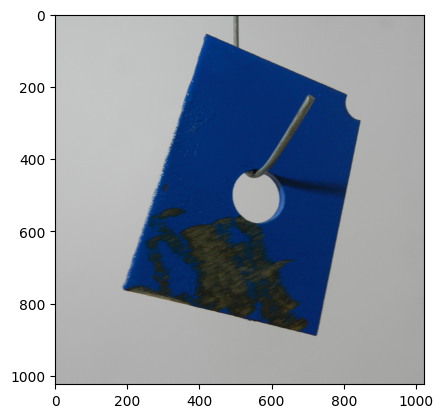

Label: scratches


In [13]:
chosen_index = random.randint(0, len(X_train)-1)
plt.imshow(Image.open(X_train[chosen_index]))
plt.show()
print(f"Label: {y_train[chosen_index]}")

In [14]:
# tensor_dims = (B, 3, 512, 512)

In [15]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.conv1 = nn.Conv2d(3, 128, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(256 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, len(CLASSES))
        self.adaptive_pool = nn.AdaptiveAvgPool2d((16, 16))
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.25)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.adaptive_pool(x)
        x = self.flatten(x) 
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [16]:
model = Classifier()
if cuda.is_available():
    model.cuda()
optimizer = SGD(model.parameters(), lr=0.005)
EPOCHS = 15

In [17]:
def load_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = image.resize((256, 256))
    image = np.array(image).astype(np.float32) / 255.0
    image = np.transpose(image, (2, 0, 1))  # Change to (C, H, W)
    
    return tensor(image).unsqueeze(0)  # Add batch dimension

In [18]:
for epoch in range(EPOCHS):
    model.train()
    overall_loss = 0.0
    for i in range(len(X_train)):
        image = load_image(X_train[i])
        label = CLASSES.index(y_train[i])
        
        if cuda.is_available():
            image = image.cuda()
            label = tensor(label).cuda().unsqueeze(0)
        
        optimizer.zero_grad()
        output = model(image)
        loss = nn.CrossEntropyLoss()(output, label)
        loss.backward()
        optimizer.step()

        overall_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS} completed. Average Loss: {overall_loss/len(X_train):.4f}")
print(f"Finished Training")

Epoch 1/15 completed. Average Loss: 0.5584
Epoch 2/15 completed. Average Loss: 0.8865
Epoch 3/15 completed. Average Loss: 0.9566
Epoch 4/15 completed. Average Loss: 0.8287
Epoch 5/15 completed. Average Loss: 0.9368
Epoch 6/15 completed. Average Loss: 0.7124
Epoch 7/15 completed. Average Loss: 0.7102
Epoch 8/15 completed. Average Loss: 0.6827
Epoch 9/15 completed. Average Loss: 0.5647
Epoch 10/15 completed. Average Loss: 0.4788
Epoch 11/15 completed. Average Loss: 0.4311
Epoch 12/15 completed. Average Loss: 0.3829
Epoch 13/15 completed. Average Loss: 0.3221
Epoch 14/15 completed. Average Loss: 0.2528
Epoch 15/15 completed. Average Loss: 0.3320
Finished Training


In [19]:
VERSION = "1b"
MODEL_NAME = f"{CHOSEN_PART}_{VERSION}_classifier.pth"
torch.save(model.state_dict(), MODEL_NAME)

In [20]:
classifier = Classifier()
classifier.load_state_dict(torch.load(MODEL_NAME))

<All keys matched successfully>

In [21]:
def decode_output(output):
    _, predicted = torch.max(output, 1)
    # print(predicted)
    return CLASSES[predicted.item()]

In [25]:
selected_index = random.randint(0, len(X_test)-1)
image_path = X_test[selected_index]
print(f"Loading image: {image_path}")
image_tensor = load_image(X_test[selected_index])
y = y_test[selected_index]
outputs = classifier(image_tensor)

Loading image: metal_plate/test/major_rust/012.png


In [26]:
print(outputs[0])
print(CLASSES)

tensor([-0.5170,  0.5643,  2.0927, -1.0870], grad_fn=<SelectBackward0>)
['good', 'major_rust', 'scratches', 'total_rust']


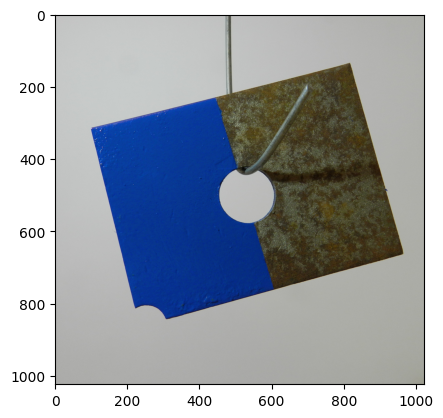

Ground Truth: major_rust
Predicted Class: scratches


In [27]:
plt.imshow(Image.open(image_path))
plt.show()
print(f"Ground Truth: {y}")
print("Predicted Class:", decode_output(outputs))